In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
df=pd.read_csv("Combined Data.CSV")
df.tail()


,Unnamed: 0,statement,status
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety
53042,53042,I have really bad door anxiety! It's not about...,Anxiety


In [5]:
risk_map={
    "Anxiety": "High Risk",
    "Stress": "High Risk",
    "Depression": "High Risk",
    "Normal": "Stable",
    "Okay": "Stable",
    "Fine": "Stable",
    "Good": "Low Risk",
    "Happy": "Low Risk",
    "Calm": "Low Risk",
    "Excited": "Low Risk",
}

In [6]:
df["risk_level"]=df["status"].map(risk_map).fillna("Stable")

In [7]:
print("class Distribution:",Counter(df["risk_level"]))

class Distribution: Counter({'Stable': 31082, 'High Risk': 21961})


In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    df["statement"], df["risk_level"], test_size=0.2, random_state=42,stratify=df["risk_level"])
print("Training set size:",X_train.shape)
print("Training test size:",X_test.shape)


Training set size: (42434,)
Training test size: (10609,)


In [9]:
df = df.dropna(subset=["statement"])


In [10]:
print(df[df["statement"].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, statement, status, risk_level]
Index: []


In [11]:
print(X_train.apply(type).value_counts())


statement
<class 'str'>      42144
<class 'float'>      290
Name: count, dtype: int64


In [12]:
# Convert all values in statement column to string
X_train = X_train.astype(str)
X_test = X_test.astype(str)


In [13]:
vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [14]:
model=LogisticRegression(max_iter=1000, C=0.1)
model.fit(X_train_vec, y_train)

LogisticRegression(C=0.1, max_iter=1000)

In [15]:
import joblib

# Save the trained TF-IDF vectorizer to a file named 'vectorizer.joblib'
joblib.dump(vectorizer, 'vectorizer.joblib')

# Save the trained Logistic Regression model to a file named 'model.joblib'
joblib.dump(model, 'model.joblib')

print("✅ Model and vectorizer have been saved successfully!")
print("Look for 'model.joblib' and 'vectorizer.joblib' in your file directory.")

✅ Model and vectorizer have been saved successfully!
Look for 'model.joblib' and 'vectorizer.joblib' in your file directory.


In [16]:
##prediction and Evaluation
y_pred =model.predict(X_test_vec)
accuracy = accuracy_score(y_test,y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report: \n",classification_report(y_test,y_pred))


Model Accuracy: 0.7687

Classification Report: 
               precision    recall  f1-score   support

   High Risk       0.75      0.66      0.70      4392
      Stable       0.78      0.85      0.81      6217

    accuracy                           0.77     10609
   macro avg       0.77      0.75      0.76     10609
weighted avg       0.77      0.77      0.77     10609



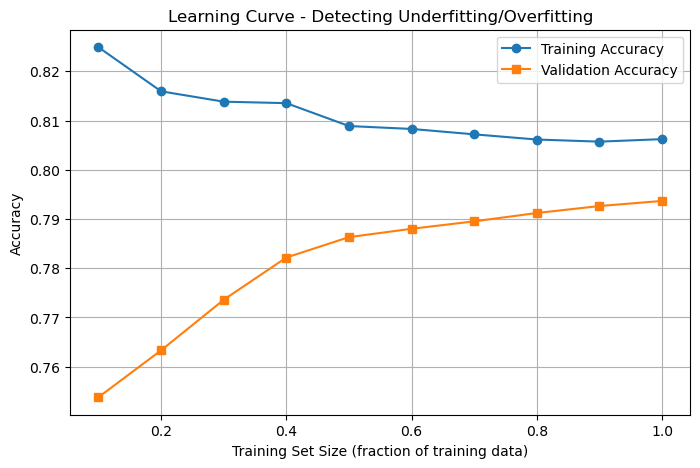

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Visualize underfitting vs overfitting using learning curves
train_sizes = np.linspace(0.1, 1.0, 10)
train_accuracies = []
test_accuracies = []

for train_size in train_sizes:
    # Use increasing portions of training data
    X_part = X_train_vec[:int(train_size * X_train_vec.shape[0])]
    y_part = y_train[:int(train_size * len(y_train))]
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_part, y_part)
    
    y_train_pred = model.predict(X_part)
    y_test_pred = model.predict(X_test_vec)
    
    train_accuracies.append(accuracy_score(y_part, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# Plot learning curve
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_accuracies, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_accuracies, label="Validation Accuracy", marker='s')
plt.title("Learning Curve - Detecting Underfitting/Overfitting")
plt.xlabel("Training Set Size (fraction of training data)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
